## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data
import yfinance as yf
from curl_cffi import requests
import math

## Datos

##### Activos

In [2]:
activos = ["NAFTRACISHRS.MX","LACOMERUBC.MX","CEMEXCPO.MX","PE&OLES.MX","VOLARA.MX", "GAP1.MX", "AMZN", "TSLA"]

session = requests.Session(impersonate="chrome")

df = yf.download(
    activos,
    start="2023-12-17",
    end="2025-01-01",
    progress=False,
    threads=False,
    session=session
)

df_precios = df["Close"]

# eliminar filas con NaN
df_precios = df_precios.dropna()

# ordenar de más reciente a más antiguo
df_precios = df_precios.sort_index(ascending=False)

df_precios

Ticker,AMZN,CEMEXCPO.MX,GAP1.MX,LACOMERUBC.MX,NAFTRACISHRS.MX,PE&OLES.MX,TSLA,VOLARA.MX
Date,,,,,,,,
2024-12-31,219.389999,11.621096,487.206818,32.366432,47.460732,265.399994,403.839996,15.56
2024-12-30,221.300003,11.313449,487.206818,31.678623,46.848087,257.549988,417.410004,15.48
2024-12-27,223.750000,11.392840,487.206818,32.061829,47.178280,272.790009,431.660004,15.52
2024-12-26,227.050003,11.363069,487.206818,32.189568,47.387531,272.980011,454.130005,15.59
2024-12-24,229.050003,11.253904,487.206818,32.150265,47.206814,276.320007,462.279999,15.65
...,...,...,...,...,...,...,...,...
2023-12-22,153.419998,13.787771,358.790527,41.511135,52.819469,248.429993,252.539993,16.10
2023-12-21,153.839996,13.629633,358.790527,40.633320,52.976173,244.000000,254.500000,15.79
2023-12-20,152.119995,13.273819,353.807281,40.955185,52.478394,241.080002,247.139999,15.41


In [3]:
df_precios.index = df_precios.index.tz_localize(None)
df_precios.to_excel(r'C:\Users\axelc\OneDrive\AppData\Documentos\Familia\Axel\Reto Actinver\Activos.xlsx')

## Grafica de las Acciones

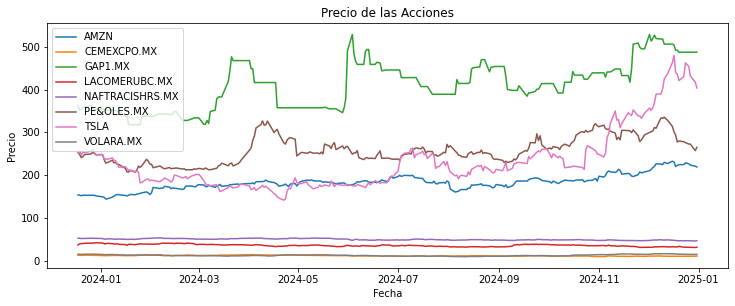

In [4]:
plt.figure(figsize = (12.2, 4.5))
for i in df_precios.columns.values:
    plt.plot(df_precios[i], label = i)
plt.title('Precio de las Acciones')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend(df_precios.columns.values)
plt.show()

## Analisis de Rendimientos

In [5]:
df_precios_ren = np.log(df_precios).diff()
df_precios_ren = df_precios_ren.dropna()
df_precios_ren

Ticker,AMZN,CEMEXCPO.MX,GAP1.MX,LACOMERUBC.MX,NAFTRACISHRS.MX,PE&OLES.MX,TSLA,VOLARA.MX
Date,,,,,,,,
2024-12-30,0.008668,-0.026830,0.000000,-0.021480,-0.012992,-0.030024,0.033050,-0.005155
2024-12-27,0.011010,0.006993,0.000000,0.012024,0.007023,0.057488,0.033569,0.002581
2024-12-26,0.014641,-0.002617,0.000000,0.003976,0.004426,0.000696,0.050745,0.004500
2024-12-24,0.008770,-0.009653,0.000000,-0.001222,-0.003821,0.012161,0.017787,0.003841
2024-12-23,-0.017573,-0.013316,0.000000,0.006701,0.003018,0.007176,-0.070991,0.007639
...,...,...,...,...,...,...,...,...
2023-12-22,0.000065,0.010811,-0.010225,-0.009820,-0.007476,-0.005940,-0.015988,0.017544
2023-12-21,0.002734,-0.011536,0.000000,-0.021373,0.002962,-0.017993,0.007731,-0.019442
2023-12-20,-0.011243,-0.026453,-0.013986,0.007890,-0.009441,-0.012039,-0.029346,-0.024360


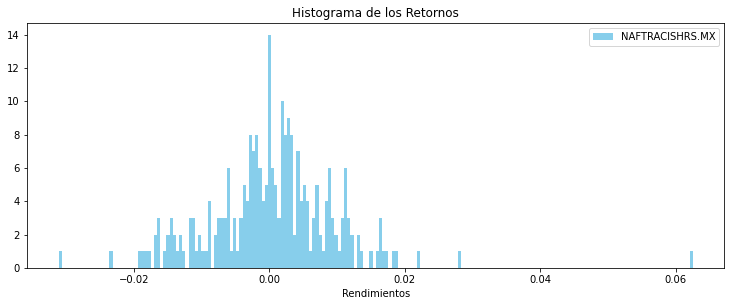

In [6]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['NAFTRACISHRS.MX'], label = 'NAFTRACISHRS.MX', bins = 200, color = 'skyblue')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

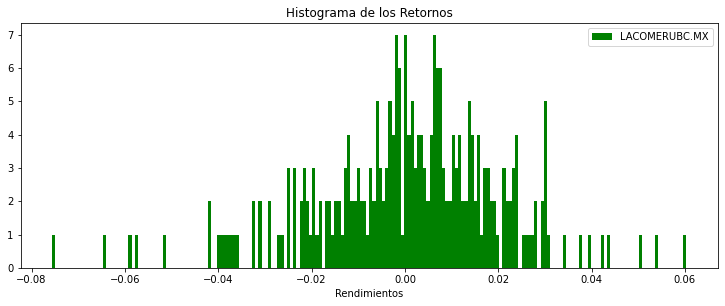

In [7]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['LACOMERUBC.MX'], label = 'LACOMERUBC.MX', bins = 200, color = 'green')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

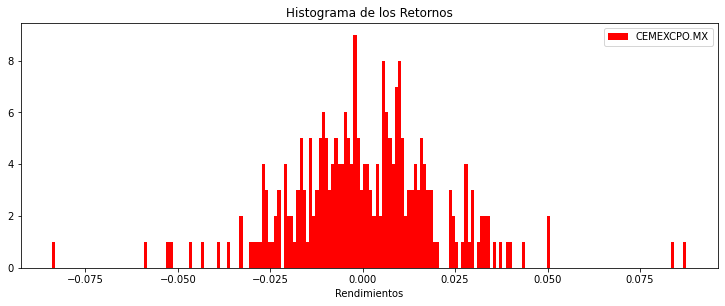

In [8]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['CEMEXCPO.MX'], label = 'CEMEXCPO.MX', bins = 200, color = 'red')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

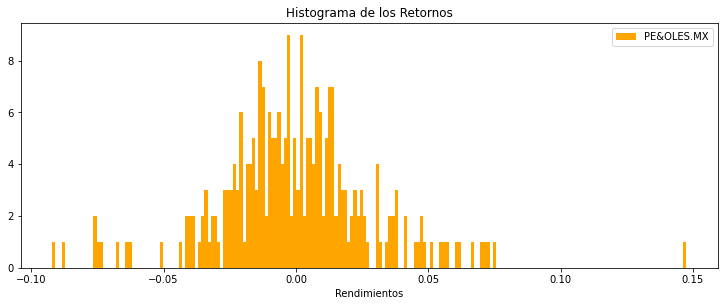

In [9]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['PE&OLES.MX'], label = 'PE&OLES.MX', bins = 200, color = 'orange')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

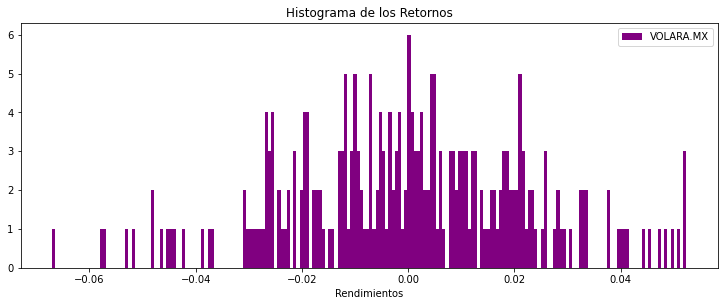

In [10]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['VOLARA.MX'], label = 'VOLARA.MX', bins = 200, color = 'purple')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

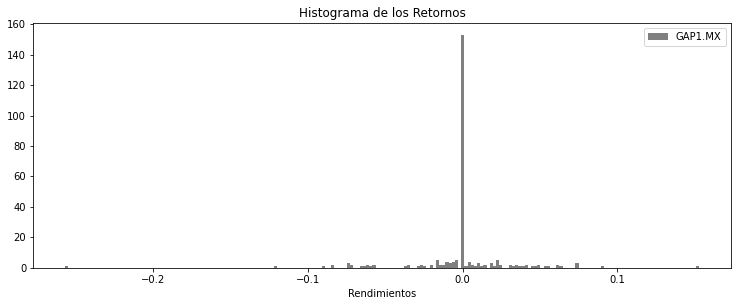

In [11]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['GAP1.MX'], label = 'GAP1.MX', bins = 200, color = 'gray')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

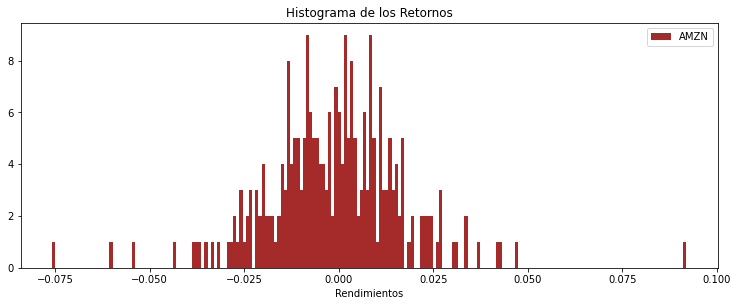

In [12]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['AMZN'], label = 'AMZN', bins = 200, color = 'brown')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

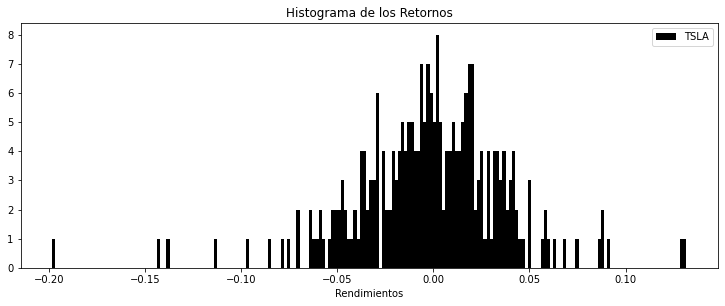

In [13]:
plt.figure(figsize=(12.5, 4.5))
plt.hist(df_precios_ren['TSLA'], label = 'TSLA', bins = 200, color = 'black')
plt.title('Histograma de los Retornos')
plt.xlabel('Rendimientos')
plt.legend()
plt.show()

## Estimadores Anuales

In [14]:
media = df_precios_ren.mean().values * 252
varianza = df_precios_ren.var().values * 252
desv_est = np.sqrt(varianza)
matrix_cov = df_precios_ren.cov() * 252

formatted_media = [f'{m: .4%}' for m in media]
formatted_varianza = [f'{m: .4%}' for m in varianza]
formatted_vol = [f'{m * 100:.4f}' for m in desv_est]


print(f'Rendimiento de las Acciones = {formatted_media} \n')
print(f'Varianza de las Acciones = {formatted_varianza} \n')
print('Volatilidad de las Acciones = ', formatted_vol, '\n')
print('Matriz de varianzas y covarianzas: \n \n', matrix_cov)

Rendimiento de las Acciones = ['-35.3444%', ' 14.3342%', '-29.4900%', ' 14.9881%', ' 11.4800%', '-4.4061%', '-47.1272%', ' 2.2873%'] 

Varianza de las Acciones = [' 8.0703%', ' 10.6449%', ' 25.8763%', ' 10.1682%', ' 2.2278%', ' 21.3550%', ' 39.4148%', ' 12.7283%'] 

Volatilidad de las Acciones =  ['28.4083', '32.6265', '50.8688', '31.8876', '14.9260', '46.2114', '62.7812', '35.6768'] 

Matriz de varianzas y covarianzas: 
 
 Ticker               AMZN  CEMEXCPO.MX   GAP1.MX  LACOMERUBC.MX  \
Ticker                                                            
AMZN             0.080703     0.018795  0.008043       0.010007   
CEMEXCPO.MX      0.018795     0.106449  0.012948       0.017983   
GAP1.MX          0.008043     0.012948  0.258763      -0.013944   
LACOMERUBC.MX    0.010007     0.017983 -0.013944       0.101682   
NAFTRACISHRS.MX  0.008445     0.023107 -0.004018       0.018958   
PE&OLES.MX       0.017881     0.030793  0.002294       0.032208   
TSLA             0.058628     0.0278

## Capital

In [15]:
capital = 1000000
print(f'Nuestro capital a invertir es de ${capital: ,.2f}')

Nuestro capital a invertir es de $ 1,000,000.00


## Portafolio Sencillo

In [16]:
# Portafolio Sencillo

# Porcentaje a invertir en cada activo
w_port_sencillo = [.125, .125, .125, .125, .125, .125, .125, .125]

# Ultimo precio observado
precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]

# Monto tenemos que invertir en cada activo
montos = [capital * i for i in w_port_sencillo]

# Numero de activos
n_activos = [math.floor(i / j) for i,j in zip(montos, precios)]

# Monto Real
monto_real = [i * j for i,j in zip(n_activos, precios)]

Port_sencillo = pd.DataFrame(zip(activos, precios, n_activos, montos, monto_real, w_port_sencillo), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_sencillo['Precios'] = Port_sencillo['Precios'].apply('${:.2f}'.format)
Port_sencillo['# Activos'] = Port_sencillo['# Activos'].apply('{:,.0f}'.format)
Port_sencillo['Monto'] = Port_sencillo['Monto'].apply('${:,.2f}'.format)
Port_sencillo['Monto Real'] = Port_sencillo['Monto Real'].apply('${:,.2f}'.format)
Port_sencillo['W1'] = Port_sencillo['W1'].apply('{:.2%}'.format)
print(Port_sencillo)

# Rendimiento del Portafolio
rend_port_sencillo = media @ w_port_sencillo
print(f'\n El Rendimiento del Portafolio es de: {rend_port_sencillo: .4%}')

# Varianza del Portafolio
var_port_sencillo = w_port_sencillo @ matrix_cov @ w_port_sencillo
print(f'\n La Varianza del Portafolio es de: {var_port_sencillo: .4%}')

# Volatilidad del Portafolio
de_port_sencillo = np.sqrt(var_port_sencillo)
print(f'\n La Volatilidad del Portafolio es de: {de_port_sencillo * 100: .4f}')

# Cociente de Sharpe
Sharpe_port_sencillo = rend_port_sencillo / de_port_sencillo
print(f'\n El cociente de Sharpe es de: {Sharpe_port_sencillo: .4f}')

           Activos  Precios # Activos        Monto   Monto Real      W1
0  NAFTRACISHRS.MX  $219.39       569  $125,000.00  $124,832.91  12.50%
1    LACOMERUBC.MX   $11.62    10,756  $125,000.00  $124,996.50  12.50%
2      CEMEXCPO.MX  $487.21       256  $125,000.00  $124,724.95  12.50%
3       PE&OLES.MX   $32.37     3,862  $125,000.00  $124,999.16  12.50%
4        VOLARA.MX   $47.46     2,633  $125,000.00  $124,964.11  12.50%
5          GAP1.MX  $265.40       470  $125,000.00  $124,738.00  12.50%
6             AMZN  $403.84       309  $125,000.00  $124,786.56  12.50%
7             TSLA   $15.56     8,033  $125,000.00  $124,993.48  12.50%

 El Rendimiento del Portafolio es de: -9.1598%

 La Varianza del Portafolio es de:  3.6646%

 La Volatilidad del Portafolio es de:  19.1430

 El cociente de Sharpe es de: -0.4785


## Portafolio de Minima Varianza

In [17]:
# Portafolio minima varianza

vector_unos = [1, 1, 1, 1, 1, 1, 1, 1]

# Porcentaje a invertir en cada activo
w_port_min_var = (np.linalg.inv(matrix_cov) @ vector_unos) / (vector_unos @ np.linalg.inv(matrix_cov) @ vector_unos)

# Ultimo precio observado

precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]

# Monto tenemos que invertir en cada activo
montos = [capital * i for i in w_port_min_var]

# Numero de activos
n_activos = [math.floor(i / j) for i,j in zip(montos, precios)]

# Monto Real
monto_real = [i * j for i,j in zip(n_activos, precios)]

Port_min_var = pd.DataFrame(zip(activos, precios, n_activos, montos, monto_real, w_port_min_var), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_min_var['Precios'] = Port_min_var['Precios'].apply('${:.2f}'.format)
Port_min_var['# Activos'] = Port_min_var['# Activos'].apply('{:,.0f}'.format)
Port_min_var['Monto'] = Port_min_var['Monto'].apply('${:,.2f}'.format)
Port_min_var['Monto Real'] = Port_min_var['Monto Real'].apply('${:,.2f}'.format)
Port_min_var['W1'] = Port_min_var['W1'].apply('{:.2%}'.format)
print(Port_min_var)

# Rendimiento del Portafolio
rend_port_min_var = media @ w_port_min_var
print(f'\n El Rendimiento del Portafolio es de: {rend_port_min_var: .4%}')

# Varianza del Portafolio
var_port_min_var = w_port_min_var @ matrix_cov @ w_port_min_var
print(f'\n La Varianza del Portafolio es de: {var_port_min_var: .4%}')

# Volatilidad del Portafolio
de_port_min_var = np.sqrt(var_port_min_var)
print(f'\n La Volatilidad del Portafolio es de: {de_port_min_var * 100: .4f}')

# Cociente de Sharpe
Sharpe_port_min_var = rend_port_min_var / de_port_min_var
print(f'\n El cociente de Sharpe es de: {Sharpe_port_min_var: .4f}')

           Activos  Precios # Activos        Monto   Monto Real      W1
0  NAFTRACISHRS.MX  $219.39       574  $126,145.34  $125,929.86  12.61%
1    LACOMERUBC.MX   $11.62    -3,584  $-41,648.73  $-41,650.01  -4.16%
2      CEMEXCPO.MX  $487.21       167   $81,459.78   $81,363.54   8.15%
3       PE&OLES.MX   $32.37       882   $28,563.60   $28,547.19   2.86%
4        VOLARA.MX   $47.46    16,862  $800,283.49  $800,282.85  80.03%
5          GAP1.MX  $265.40      -187  $-49,535.48  $-49,629.80  -4.95%
6             AMZN  $403.84         5    $2,028.39    $2,019.20   0.20%
7             TSLA   $15.56     3,387   $52,703.60   $52,701.72   5.27%

 El Rendimiento del Portafolio es de:  2.4008%

 La Varianza del Portafolio es de:  1.7388%

 La Volatilidad del Portafolio es de:  13.1862

 El cociente de Sharpe es de:  0.1821


## Portafolio de Maximo Cociente de Sharpe

In [18]:
# Portafolio Max Sharpe

vector_unos = [1, 1, 1, 1, 1, 1, 1, 1]

# Porcentaje a invertir en cada activo
w_port_max_sharpe = (np.linalg.inv(matrix_cov) @ media) / (vector_unos @ np.linalg.inv(matrix_cov) @ media)

# Ultimo precio observado

precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]

# Monto tenemos que invertir en cada activo
montos = [capital * i for i in w_port_max_sharpe]

# Numero de activos
n_activos = [math.floor(i / j) for i,j in zip(montos, precios)]

# Monto Real
monto_real = [i * j for i,j in zip(n_activos, precios)]

Port_max_sharpe = pd.DataFrame(zip(activos, precios, n_activos, montos, monto_real, w_port_max_sharpe), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_max_sharpe['Precios'] = Port_max_sharpe['Precios'].apply('${:.2f}'.format)
Port_max_sharpe['# Activos'] = Port_max_sharpe['# Activos'].apply('{:,.0f}'.format)
Port_max_sharpe['Monto'] = Port_max_sharpe['Monto'].apply('${:,.2f}'.format)
Port_max_sharpe['Monto Real'] = Port_max_sharpe['Monto Real'].apply('${:,.2f}'.format)
Port_max_sharpe['W1'] = Port_max_sharpe['W1'].apply('{:.2%}'.format)
print(Port_max_sharpe)


# Rendimiento del Portafolio
rend_port_max_sharpe = media @ w_port_max_sharpe
print(f'\n El Rendimiento del Portafolio es de: {rend_port_max_sharpe: .4%}')

# Varianza del Portafolio
var_port_max_sharpe = w_port_max_sharpe @ matrix_cov @ w_port_max_sharpe
print(f'\n La Varianza del Portafolio es de: {var_port_max_sharpe: .4%}')

# Volatilidad del Portafolio
de_port_max_sharpe = np.sqrt(var_port_max_sharpe)
print(f'\n La Volatilidad del Portafolio es de: {de_port_max_sharpe * 100: .4f}')

# Cociente de Sharpe
Sharpe_port_max_sharpe = rend_port_max_sharpe / de_port_max_sharpe
print(f'\n El cociente de Sharpe es de: {Sharpe_port_max_sharpe: .4f}')

           Activos  Precios # Activos           Monto      Monto Real  \
0  NAFTRACISHRS.MX  $219.39   -15,719  $-3,448,374.21  $-3,448,591.40   
1    LACOMERUBC.MX   $11.62    72,822     $846,279.15     $846,271.43   
2      CEMEXCPO.MX  $487.21    -1,223    $-595,543.25    $-595,853.94   
3       PE&OLES.MX   $32.37    14,180     $458,963.46     $458,956.01   
4        VOLARA.MX   $47.46    96,626   $4,585,983.36   $4,585,940.64   
5          GAP1.MX  $265.40    -2,394    $-635,113.55    $-635,367.59   
6             AMZN  $403.84    -1,060    $-428,028.54    $-428,070.40   
7             TSLA   $15.56    13,871     $215,833.58     $215,832.77   

         W1  
0  -344.84%  
1    84.63%  
2   -59.55%  
3    45.90%  
4   458.60%  
5   -63.51%  
6   -42.80%  
7    21.58%  

 El Rendimiento del Portafolio es de:  234.5638%

 La Varianza del Portafolio es de:  169.8810%

 La Volatilidad del Portafolio es de:  130.3384

 El cociente de Sharpe es de:  1.7997


## Portafolio de Min. Riesgo con Rendimiento Esperado

In [19]:
# Portafolio de Minimo Riesgo con Rendimiento Esperado

vector_unos = [1, 1, 1, 1, 1, 1, 1, 1]

A = vector_unos @ np.linalg.inv(matrix_cov) @ vector_unos
B = vector_unos @ np.linalg.inv(matrix_cov) @ media
C = media @ np.linalg.inv(matrix_cov) @ media

rend_deseado = np.arange(0, 1.01, 0.01)

l = [(C - B * i) / (A * C - (B**2)) for i in rend_deseado]

LA = [i * A for i in l]
nB = [1 - i for i in LA]

for k in range(len(w_port_min_var)):
    globals()["w_min_esp_" + str(k+1)] = [i * w_port_min_var[k] + j * w_port_max_sharpe[k] for i,j in zip(LA, nB)]
    
v_w = []    
for i in range(len(w_min_esp_1)):
    v_w.append([w_min_esp_1[i], w_min_esp_2[i], w_min_esp_3[i], w_min_esp_4[i], w_min_esp_5[i], w_min_esp_6[i], w_min_esp_7[i], w_min_esp_8[i]])
    
rend_port_min_esp = [i @ media for i in v_w] 
de_port_min_esp = [np.sqrt(i @ matrix_cov @ i) for i in v_w]

Sharpe_port_min_esp = [rend_port_min_esp[i] / de_port_min_esp[i] for i in range(len(rend_port_min_esp))]

v_w_df = pd.DataFrame(v_w, columns=['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8'])
v_w_df['Suma w_s'] = v_w_df.sum(axis=1)
Port_min_esp = pd.DataFrame(zip(rend_deseado, l, LA, nB), columns = ['Rendimientos', 'λ', 'λA', 'ηB'])
rend_de_df = pd.DataFrame(zip(rend_port_min_esp, de_port_min_esp), columns=['rp', 'σp'])
sharpe_df = pd.DataFrame(Sharpe_port_min_esp, columns = ['Cociente de Sharpe'])

Port_min_esp = pd.concat([Port_min_esp, v_w_df, rend_de_df, sharpe_df], axis=1)
styled_Port_min_esp = Port_min_esp.style.format({
    'Rendimientos': '{:.0%}',
    'λ': '{:.4f}',
    'λA': '{:.4f}',
    'ηB': '{:.4f}',
    'w1': '{:.2%}',
    'w2': '{:.2%}',
    'w3': '{:.2%}',
    'w4': '{:.2%}',
    'w5': '{:.2%}',
    'w6': '{:.2%}',
    'w7': '{:.2%}',
    'w8': '{:.2%}',
    'Suma w_s': '{:.2%}',
    'rp': '{:.0%}',
    'σp': '{:.4%}',
    'Cociente de Sharpe': '{:.4f}'
})

styled_Port_min_esp

,Rendimientos,λ,λA,ηB,w1,w2,w3,w4,w5,w6,w7,w8,Suma w_s,rp,σp,Cociente de Sharpe
0,0%,0.0176,1.0103,-0.0103,16.31%,-5.08%,8.85%,2.41%,76.11%,-4.35%,0.65%,5.10%,100.00%,0%,13.2542%,0.0000
1,1%,0.0175,1.0060,-0.0060,14.77%,-4.70%,8.55%,2.60%,77.74%,-4.60%,0.46%,5.17%,100.00%,1%,13.2094%,0.0757
2,2%,0.0174,1.0017,-0.0017,13.23%,-4.32%,8.26%,2.78%,79.37%,-4.85%,0.28%,5.24%,100.00%,2%,13.1881%,0.1517
3,3%,0.0173,0.9974,0.0026,11.69%,-3.94%,7.97%,2.97%,81.01%,-5.10%,0.09%,5.31%,100.00%,3%,13.1904%,0.2274
4,4%,0.0173,0.9931,0.0069,10.15%,-3.55%,7.68%,3.15%,82.64%,-5.36%,-0.09%,5.38%,100.00%,4%,13.2164%,0.3027
5,5%,0.0172,0.9888,0.0112,8.61%,-3.17%,7.39%,3.34%,84.27%,-5.61%,-0.28%,5.45%,100.00%,5%,13.2658%,0.3769
6,6%,0.0171,0.9845,0.0155,7.07%,-2.79%,7.10%,3.52%,85.90%,-5.86%,-0.46%,5.52%,100.00%,6%,13.3385%,0.4498
7,7%,0.0170,0.9802,0.0198,5.53%,-2.41%,6.80%,3.71%,87.53%,-6.11%,-0.65%,5.59%,100.00%,7%,13.4341%,0.5211
8,8%,0.0170,0.9759,0.0241,3.99%,-2.02%,6.51%,3.89%,89.16%,-6.37%,-0.83%,5.66%,100.00%,8%,13.5519%,0.5903
9,9%,0.0169,0.9716,0.0284,2.45%,-1.64%,6.22%,4.08%,90.79%,-6.62%,-1.02%,5.73%,100.00%,9%,13.6916%,0.6573


In [20]:
max_sharpe = Port_min_esp['Cociente de Sharpe'].max()
max_sharpe_index = Port_min_esp['Cociente de Sharpe'].idxmax()
fila_max_sharpe = Port_min_esp.iloc[max_sharpe_index]

print(f"Máximo Cociente de Sharpe: {max_sharpe}")

Máximo Cociente de Sharpe: 1.7830365852657426


In [21]:
# Ultimo precio observado

precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]

# Monto tenemos que invertir en cada activo
montos = [capital * i for i in v_w[max_sharpe_index]]

# Numero de activos
n_activos = [math.floor(i / j) for i,j in zip(montos, precios)]

# Monto Real
monto_real = [i * j for i,j in zip(n_activos, precios)]

Port_min_esp_max = pd.DataFrame(zip(activos, precios, n_activos, montos, monto_real, v_w[max_sharpe_index]), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_min_esp_max['Precios'] = Port_min_esp_max['Precios'].apply('${:.2f}'.format)
Port_min_esp_max['# Activos'] = Port_min_esp_max['# Activos'].apply('{:,.0f}'.format)
Port_min_esp_max['Monto'] = Port_min_esp_max['Monto'].apply('${:,.2f}'.format)
Port_min_esp_max['Monto Real'] = Port_min_esp_max['Monto Real'].apply('${:,.2f}'.format)
Port_min_esp_max['W1'] = Port_min_esp_max['W1'].apply('{:.2%}'.format)
print(Port_min_esp_max)

# Rendimiento del Portafolio
print(f"\n El Rendimiento del Portafolio es de: {Port_min_esp.loc[max_sharpe_index, 'rp']: .2%}")

# Varianza del Portafolio
var_min_esp_max = Port_min_esp.loc[max_sharpe_index, 'σp']**2
print(f"\n La Varianza del Portafolio es de: {var_min_esp_max: .4%}")

# Volatilidad del Portafolio
de_min_esp_max = np.sqrt(Port_min_esp.loc[max_sharpe_index, 'σp'])
print(f"\n La Volatilidad del Portafolio es de: {Port_min_esp.loc[max_sharpe_index, 'σp'] * 100: .4f}")

# Cociente de Sharpe
print(f"\n El cociente de Sharpe es de: {Port_min_esp['Cociente de Sharpe'].max(): .4f}")


           Activos  Precios # Activos           Monto      Monto Real  \
0  NAFTRACISHRS.MX  $219.39    -6,275  $-1,376,549.78  $-1,376,672.25   
1    LACOMERUBC.MX   $11.62    28,536     $331,627.98     $331,619.59   
2      CEMEXCPO.MX  $487.21      -417    $-203,146.06    $-203,165.24   
3       PE&OLES.MX   $32.37     6,472     $209,499.74     $209,475.55   
4        VOLARA.MX   $47.46    50,394   $2,391,756.88   $2,391,736.10   
5          GAP1.MX  $265.40    -1,115    $-295,707.11    $-295,920.99   
6             AMZN  $403.84      -443    $-178,763.58    $-178,901.12   
7             TSLA   $15.56     7,794     $121,281.94     $121,274.64   

         W1  
0  -137.65%  
1    33.16%  
2   -20.31%  
3    20.95%  
4   239.18%  
5   -29.57%  
6   -17.88%  
7    12.13%  

 El Rendimiento del Portafolio es de:  100.00%

 La Varianza del Portafolio es de:  31.4543%

 La Volatilidad del Portafolio es de:  56.0841

 El cociente de Sharpe es de:  1.7830


## Portafolio Libre de Riesgo

In [22]:
# Portafolio sin riesgo

# Cetes, Bonddia, Sofipos (Ualá)

w_sin_riesgo = [0.15, 0.30, 0.55]
r_sin_riesgo = np.array([0.073, 0.07, 0.14])

rend_port_rf = w_sin_riesgo @ r_sin_riesgo

print(f'El rendimiento de Nuestro Portafolio Libre de Riesgo es de {rend_port_rf: .4%}')

El rendimiento de Nuestro Portafolio Libre de Riesgo es de  10.8950%


## Portafolio de Tangencia

In [23]:
# Portafolio de tangencias o de mercado

vector_unos = [1, 1, 1, 1, 1, 1, 1, 1]
matrix_cov_inv = np.linalg.inv(matrix_cov)

F = [i - rend_port_rf for i in media]

w_port_tan = (matrix_cov_inv @ F) / (vector_unos @ matrix_cov_inv @ F)

# Ultimo precio observado

precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]

# Monto de inversion en cada activo
montos_port_tan = [capital * i for i in w_port_tan]

# Numero de activo
n_activos_port_tan = [math.floor(i / j) for i, j in zip(montos_port_tan, precios)]

# Monto real
monto_real_port_tan = [i * j for i, j in zip(precios, n_activos_port_tan)]

Port_tan = pd.DataFrame(zip(activos, precios, n_activos_port_tan, montos_port_tan, monto_real_port_tan, w_port_tan), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_tan['Precios'] = Port_tan['Precios'].apply('${:.2f}'.format)
Port_tan['# Activos'] = Port_tan['# Activos'].apply('{:,.0f}'.format)
Port_tan['Monto'] = Port_tan['Monto'].apply('${:,.2f}'.format)
Port_tan['Monto Real'] = Port_tan['Monto Real'].apply('${:,.2f}'.format)
Port_tan['W1'] = Port_tan['W1'].apply('{:.2%}'.format)
print(Port_tan)

# Rendimiento del Portafolio
rend_port_tan = media @ w_port_tan
print(f'\n El Rendimiento del Portafolio es de: {rend_port_tan: .4%}')

# Varianza del Portafolio
var_port_tan = w_port_tan @ matrix_cov @ w_port_tan
print(f'\n La Varianza del Portafolio es de: {var_port_tan: .4%}')

# Volatilidad del Portafolio
de_port_tan = np.sqrt(var_port_tan)
print(f'\n La Volatilidad del Portafolio es de: {de_port_tan * 100: .4f}')

# Cociente de Sharpe
Sharpe_port_tan = rend_port_tan / de_port_tan
print(f'\n El cociente de Sharpe es de: {Sharpe_port_tan: .4f}')

# Sharpe Ajustado
sharpe_ajus_port_tan = (rend_port_tan - rend_port_rf) / de_port_tan
print(f'\n El cociente de Sharpe Ajustado es de: {sharpe_ajus_port_tan: .4f}')

           Activos  Precios # Activos          Monto     Monto Real       W1
0  NAFTRACISHRS.MX  $219.39     5,179  $1,136,439.80  $1,136,220.81  113.64%
1    LACOMERUBC.MX   $11.62   -25,180   $-292,610.74   $-292,619.19  -29.26%
2      CEMEXCPO.MX  $487.21       559    $272,806.45    $272,348.61   27.28%
3       PE&OLES.MX   $32.37    -2,876    $-93,083.68    $-93,085.86   -9.31%
4        VOLARA.MX   $47.46    -5,683   $-269,698.51   $-269,719.34  -26.97%
5          GAP1.MX  $265.40       436    $115,971.04    $115,714.40   11.60%
6             AMZN  $403.84       306    $123,578.75    $123,575.04   12.36%
7             TSLA   $15.56       423      $6,596.90      $6,581.88    0.66%

 El Rendimiento del Portafolio es de: -63.2173%

 La Varianza del Portafolio es de:  15.1706%

 La Volatilidad del Portafolio es de:  38.9495

 El cociente de Sharpe es de: -1.6231

 El cociente de Sharpe Ajustado es de: -1.9028


## Market Capital Line

In [24]:
vol_cml = np.arange(0, 1.1, 0.01)
rfr = [rend_port_rf + (sharpe_ajus_port_tan * i) for i in vol_cml]

de_deseada = round(.152635, 4)
CML = pd.DataFrame(zip(rfr, vol_cml), columns = ['ren', 'vol'])
CML.set_index('vol', inplace = True)

rendimiento_interpolado = np.interp(de_deseada, CML.index, CML['ren'])

print(f'Rendimiento con la Volatilidad deseada es de ', round(rendimiento_interpolado * 100, 4), '%')

Rendimiento con la Volatilidad deseada es de  -18.1414 %


## Grafica de los Portafolios

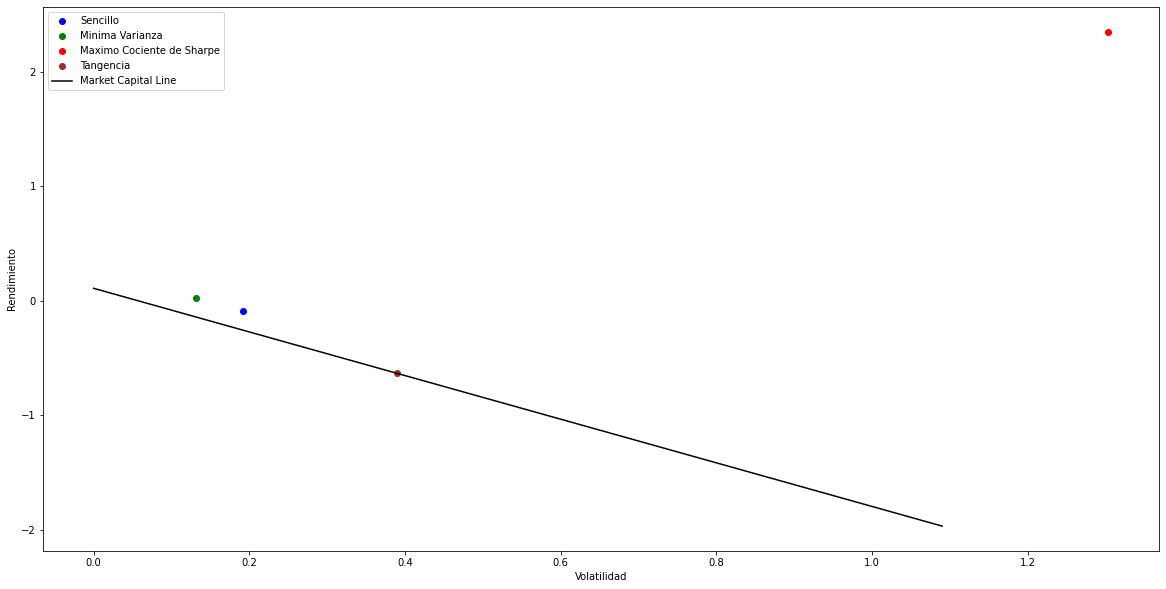

In [25]:
plt.figure(figsize=(20, 10))

plt.plot(de_port_sencillo, rend_port_sencillo, 'o', label='Sencillo', color='blue')
plt.plot(de_port_min_var, rend_port_min_var, 'o', label='Minima Varianza', color='green')
plt.plot(de_port_max_sharpe, rend_port_max_sharpe, 'o', label='Maximo Cociente de Sharpe', color='red')
#plt.plot(de_port_min_esp, rend_port_min_esp, label='Frontera Eficiente', color='purple')
#plt.plot(Port_min_esp.loc[max_sharpe_index, 'σp'], Port_min_esp.loc[max_sharpe_index, 'rp'], 'o', label='Minimo Riesgo', color='orange')
plt.plot(de_port_tan, rend_port_tan, 'o', label='Tangencia', color='brown')
plt.plot(vol_cml, rfr, label='Market Capital Line', color='black')

plt.legend()

plt.ylabel('Rendimiento')
plt.xlabel('Volatilidad')

plt.show()


## Portafolio con y sin riesgo

In [26]:
w_PA = de_deseada / de_port_tan
w_Arf = 1- w_PA
print(f'Porcentaje en el portafolio de acciones {w_PA: .4%}')
print(f'Porcentaje en el portafolio de acciones libres de riesgo {w_Arf: .4%}')

Porcentaje en el portafolio de acciones  39.1789%
Porcentaje en el portafolio de acciones libres de riesgo  60.8211%


In [27]:
activos_rf = ['Cetes', 'Bonddia', 'Sofipo (Uala)']

activos_np = activos + activos_rf

# Ultimo precio observado
precios = [df_precios.loc['2024-12-31', df_precios.columns[i]] for i in range(len(df_precios.columns))]
precios_np = precios + [100, 100, 100]

# Monto de inversion en cada activo
monto_por_r = [capital * i * w_PA for i in w_port_tan]
monto_por_rf = [capital * i * w_Arf for i in w_sin_riesgo]

montos_np = monto_por_r + monto_por_rf

# Numero de activo
n_activos_port_np = [math.floor(i / j) for i, j in zip(montos_np, precios_np)]

# Monto real
monto_real_port_np = [i * j for i, j in zip(precios_np, n_activos_port_np)]

rend_np = media.tolist() + r_sin_riesgo.tolist()

w_np = [i / capital for i in montos_np]

rend_port_np = np.array(rend_np) @ w_np

Port_np = pd.DataFrame(zip(activos_np, precios_np, n_activos_port_np, montos_np, monto_real_port_np, w_np), columns = ['Activos', 'Precios', '# Activos', 'Monto', 'Monto Real', 'W1'])
Port_np['Precios'] = Port_np['Precios'].apply('${:.2f}'.format)
Port_np['# Activos'] = Port_np['# Activos'].apply('{:,.0f}'.format)
Port_np['Monto'] = Port_np['Monto'].apply('${:,.2f}'.format)
Port_np['Monto Real'] = Port_np['Monto Real'].apply('${:,.2f}'.format)
Port_np['W1'] = Port_np['W1'].apply('{:.2%}'.format)
print(Port_np)

# Rendimiento del Portafolio
rend_port_np = np.array(rend_np) @ w_np
print(f'\n El Rendimiento del Portafolio es de: {rend_port_np: .4%}')

            Activos  Precios # Activos         Monto    Monto Real       W1
0   NAFTRACISHRS.MX  $219.39     2,029   $445,244.84   $445,142.31   44.52%
1     LACOMERUBC.MX   $11.62    -9,865  $-114,641.73  $-114,642.11  -11.46%
2       CEMEXCPO.MX  $487.21       219   $106,882.62   $106,698.29   10.69%
3        PE&OLES.MX   $32.37    -1,127   $-36,469.18   $-36,476.97   -3.65%
4         VOLARA.MX   $47.46    -2,227  $-105,664.96  $-105,695.05  -10.57%
5           GAP1.MX  $265.40       171    $45,436.20    $45,383.40    4.54%
6              AMZN  $403.84       119    $48,416.82    $48,056.96    4.84%
7              TSLA   $15.56       166     $2,584.59     $2,582.96    0.26%
8             Cetes  $100.00       912    $91,231.62    $91,200.00    9.12%
9           Bonddia  $100.00     1,824   $182,463.24   $182,400.00   18.25%
10    Sofipo (Uala)  $100.00     3,345   $334,515.94   $334,500.00   33.45%

 El Rendimiento del Portafolio es de: -18.1414%


## Betas de los Activos respecto al Mercado

In [28]:
df_precios = pd.DataFrame()

activos=["NAFTRACISHRS.MX","LACOMERUBC.MX","CEMEXCPO.MX","PE&OLES.MX","VOLARA.MX", "GAP1.MX", "^MXX"]

for i in activos:
    df_precios[i]=pd.DataFrame(yf.Ticker(i).history(start="2023-12-17", end="2025-01-01")['Close'])
df_precios

,NAFTRACISHRS.MX,LACOMERUBC.MX,CEMEXCPO.MX,PE&OLES.MX,VOLARA.MX,GAP1.MX,^MXX
Date,,,,,,,
2023-12-18 00:00:00-06:00,53.234276,37.599960,13.412190,253.960007,15.92,362.777069,57732.808594
2023-12-19 00:00:00-06:00,53.178959,39.892044,13.451726,248.539993,15.93,351.814026,57694.339844
2023-12-20 00:00:00-06:00,52.478394,40.955185,13.273819,241.080002,15.41,353.807281,56909.371094
2023-12-21 00:00:00-06:00,52.976173,40.633320,13.629633,244.000000,15.79,358.790527,57487.699219
2023-12-22 00:00:00-06:00,52.819469,41.511135,13.787771,248.429993,16.10,358.790527,57313.468750
...,...,...,...,...,...,...,...
2024-12-24 00:00:00-06:00,47.206814,32.150265,11.253904,276.320007,15.65,487.206818,49316.621094
2024-12-26 00:00:00-06:00,47.387531,32.189568,11.363069,272.980011,15.59,487.206818,49535.578125
2024-12-27 00:00:00-06:00,47.178280,32.061829,11.392840,272.790009,15.52,487.206818,49290.578125


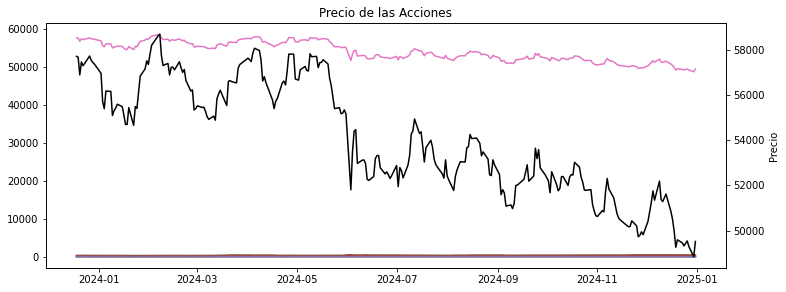

In [29]:
fig, ax1 = plt.subplots(figsize = (12.2, 4.5))
for i in ["NAFTRACISHRS.MX","LACOMERUBC.MX","CEMEXCPO.MX","PE&OLES.MX","VOLARA.MX", "GAP1.MX", "^MXX"]:
    ax1.plot(df_precios[i])
    
ax2 = ax1.twinx()
ax2.plot(df_precios['^MXX'], color = 'black')

plt.title('Precio de las Acciones')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.show()

In [30]:
df_precios_ren = np.log(df_precios).diff()
df_precios_ren = df_precios_ren.dropna()

In [31]:
media = df_precios_ren.mean().values * 252
varianza = df_precios_ren.var().values * 252
desv_est = np.sqrt(varianza)
matrix_cov = df_precios_ren.cov() * 252

formatted_media = [f'{m: .4%}' for m in media]
formatted_varianza = [f'{m: .4%}' for m in varianza]
formatted_vol = [f'{m * 100:.4f}' for m in desv_est]


print(f'Rendimiento de las Acciones = {formatted_media} \n')
print(f'Varianza de las Acciones = {formatted_varianza} \n')
print('Volatilidad de las Acciones = ', formatted_vol, '\n')
print('Matriz de varianzas y covarianzas: \n \n', matrix_cov)

Rendimiento de las Acciones = ['-11.1697%', '-14.5830%', '-13.9468%', ' 4.2870%', '-2.2254%', ' 28.6930%', '-14.9434%'] 

Varianza de las Acciones = [' 2.2169%', ' 10.0002%', ' 10.3729%', ' 20.6795%', ' 12.5292%', ' 25.1779%', ' 2.2831%'] 

Volatilidad de las Acciones =  ['14.8892', '31.6231', '32.2070', '45.4747', '35.3967', '50.1776', '15.1099'] 

Matriz de varianzas y covarianzas: 
 
                  NAFTRACISHRS.MX  LACOMERUBC.MX  CEMEXCPO.MX  PE&OLES.MX  \
NAFTRACISHRS.MX         0.022169       0.018131     0.022565    0.029349   
LACOMERUBC.MX           0.018131       0.100002     0.017664    0.031187   
CEMEXCPO.MX             0.022565       0.017664     0.103729    0.029392   
PE&OLES.MX              0.029349       0.031187     0.029392    0.206795   
VOLARA.MX               0.013042       0.028618     0.016274    0.035565   
GAP1.MX                -0.003689      -0.013030     0.011127    0.002784   
^MXX                    0.021537       0.018677     0.023600    0.033335   



In [32]:
activos_2 = ["NAFTRACISHRS.MX","LACOMERUBC.MX","CEMEXCPO.MX","PE&OLES.MX","VOLARA.MX", "GAP1.MX", "^MXX"]
cov_act_ipc = [matrix_cov.loc[i, '^MXX'] for i in activos_2]

betas = [i / matrix_cov.loc['^MXX', '^MXX'] for i in cov_act_ipc]

rm = media[5]
rf = 0.11
CAPM = [rf + (i * (rm - rf)) for i in betas] # Rendimiento esperado de la accion

Modelo_CAPM = pd.DataFrame(zip(activos_2, media[0:11], betas, CAPM), columns = ['Activos', 'r_obs', 'betas', 'r_capm'])
Modelo_CAPM.sort_values('r_capm')
Modelo_CAPM.set_index('Activos', inplace = True)
styled_modelo_CAPM = Modelo_CAPM.style.format({
    'r_obs': '{:.2%}',
    'r_capm': '{:.2%}'
})
styled_modelo_CAPM

,r_obs,betas,r_capm
Activos,,,
NAFTRACISHRS.MX,-11.17%,0.943320,27.69%
LACOMERUBC.MX,-14.58%,0.818082,25.47%
CEMEXCPO.MX,-13.95%,1.033711,29.29%
PE&OLES.MX,4.29%,1.460071,36.83%
VOLARA.MX,-2.23%,0.613174,21.85%
GAP1.MX,28.69%,-0.104309,9.15%
^MXX,-14.94%,1.000000,28.69%


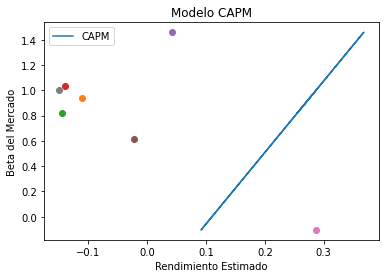

In [33]:
plt.plot(Modelo_CAPM['r_capm'], Modelo_CAPM['betas'])

for i in activos_2:
    plt.plot(Modelo_CAPM.loc[i, 'r_obs'], Modelo_CAPM.loc[i, 'betas'], 'o')
    
plt.title('Modelo CAPM')
plt.xlabel('Rendimiento Estimado')
plt.ylabel('Beta del Mercado')
plt.legend(['CAPM'])
plt.show()